In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix)

### Data preparation

In [2]:
# Load dataset
df = pd.read_excel("heart_disease.xlsx",sheet_name="Heart_disease")
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


### Exploratory Data Analysis (EDA):

In [3]:
df.shape

(908, 13)

In [4]:
df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [5]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,907.0,53.787211,9.162016,29.0,47.5,54.0,60.0,77.0
trestbps,907.0,133.412348,20.405432,0.0,120.0,130.0,144.0,200.0
chol,907.0,201.465270,112.158285,0.0,176.5,224.0,270.0,603.0
thalch,907.0,135.976847,26.813075,60.0,118.0,138.0,156.0,202.0
oldpeak,845.0,0.892308,1.094092,-2.6,0.0,0.5,1.5,6.2
num,907.0,1.007718,1.144594,0.0,0.0,1.0,2.0,4.0


In [9]:
# Categorical summary (if any)
cat_cols = df.select_dtypes(include=["object","category"]).columns.tolist()
if cat_cols:
    display(df[cat_cols].nunique().to_frame("unique_vals"))

,unique_vals
sex,2
cp,4
restecg,3
exang,4
slope,3
thal,3


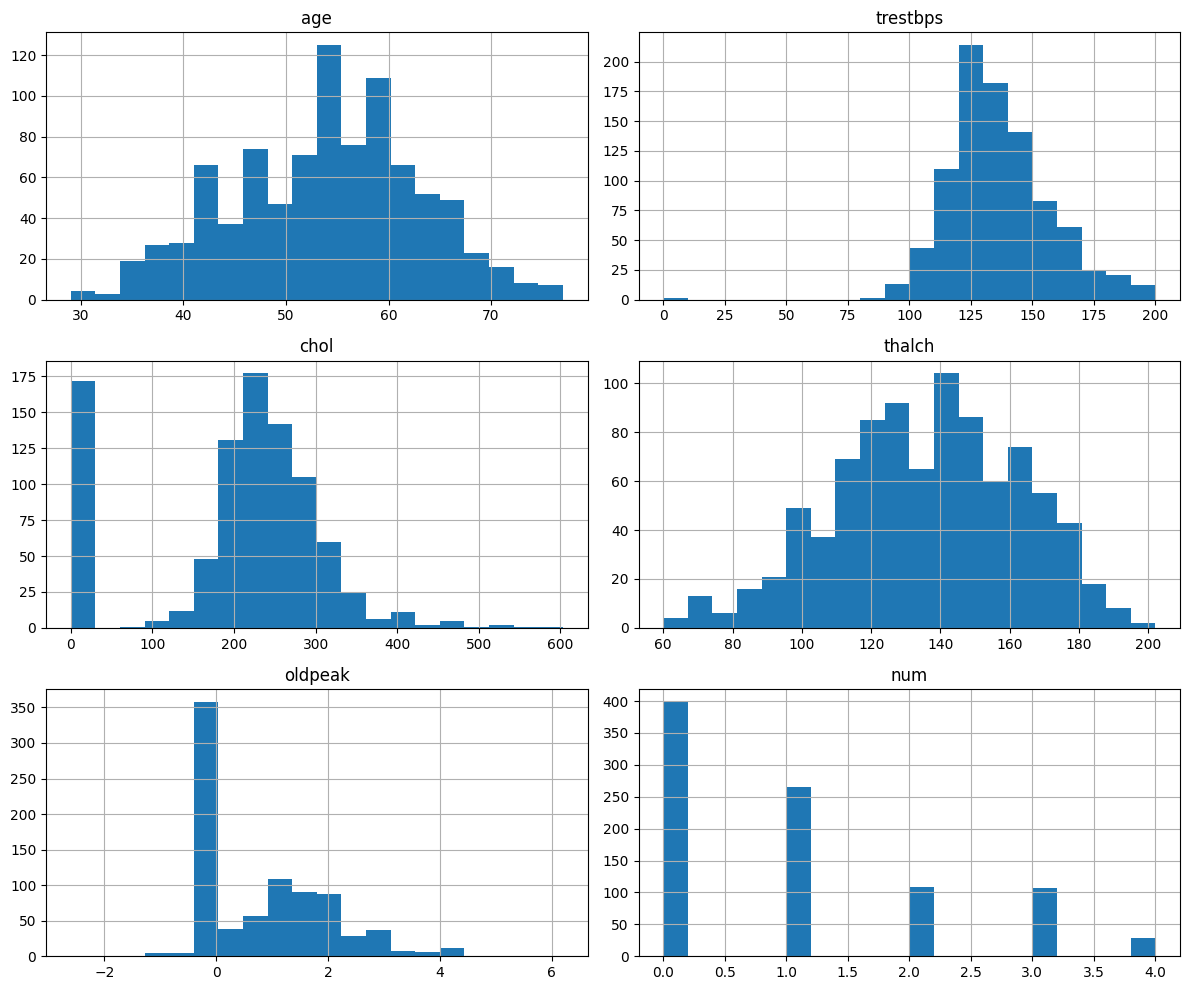

In [10]:
# Histograms for numeric columns (auto)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

- The histograms show that most numeric variables are moderately distributed, though cholesterol and oldpeak are right-skewed.
- Resting blood pressure and cholesterol contain zero values, which are medically unrealistic and may represent data entry issues.
- The target variable is imbalanced, with a higher proportion of class 0, justifying the use of class weighting and ROC-AUC for evaluation.

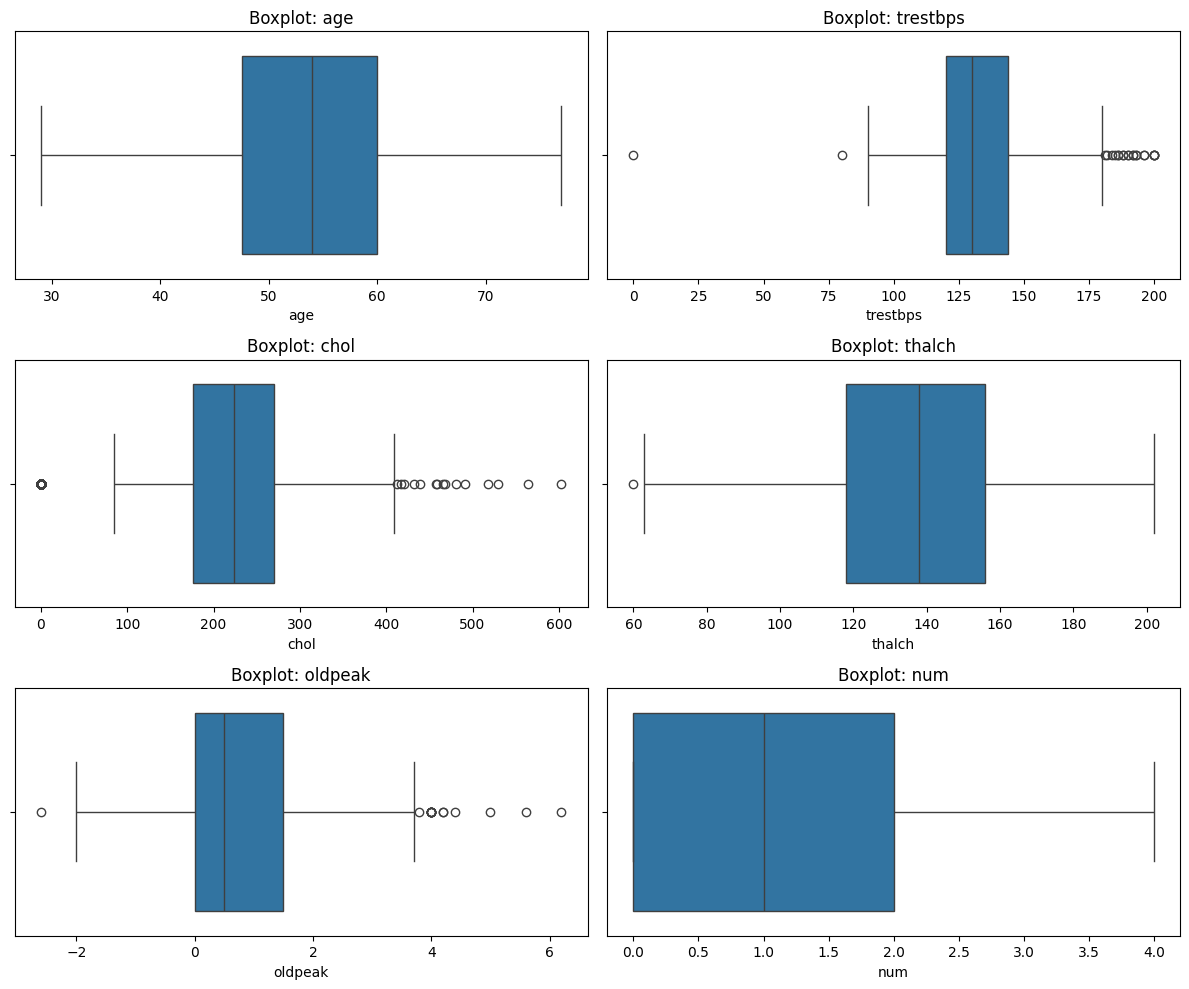

In [11]:
# Boxplots to visually inspect outliers for top 6 numeric features
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, col in enumerate(num_cols[:6]):
    sns.boxplot(x=df[col], ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

- Boxplots reveal the presence of outliers in cholesterol, resting blood pressure, and oldpeak. Some zero values in trestbps and chol appear unrealistic and may represent data entry errors.
- However, since Decision Trees are robust to outliers and do not rely on distance metrics, these extreme values will be retained.

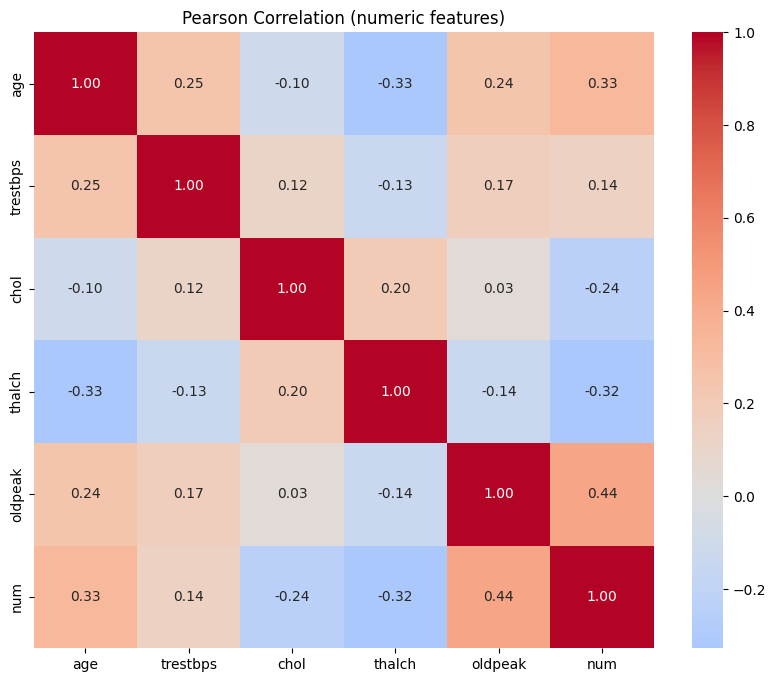

In [12]:
# Correlation matrix heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson Correlation (numeric features)")
plt.show()

### Feature Engineering

In [13]:
df["num"] = (df["num"] > 0).astype(int)

In [14]:
X = df.drop("num", axis=1)
y = df["num"]

In [15]:
# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [16]:
for c in num_cols:
    X[c] = X[c].fillna(X[c].median())

for c in cat_cols:
    X[c] = X[c].fillna(X[c].mode()[0])

In [17]:
X = pd.get_dummies(X, drop_first=True)

**Encoding of Categorical Variables-**

- Categorical variables were identified and encoded using One-Hot Encoding.
- Since all categorical features have low cardinality (≤ 5 unique values), One-Hot Encoding was applied using pd.get_dummies() with drop_first=True to prevent multicollinearity.
- Label encoding was not required because there were no high-cardinality categorical variables in the dataset.

### Decision Tree Classification:

In [18]:
# Train/test split (80-20 stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [19]:
# Initialize and train Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [20]:
# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1] if hasattr(clf, "predict_proba") else None

In [21]:
# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, zero_division=0))
if y_proba is not None:
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7307692307692307
Precision: 0.7476635514018691
Recall: 0.7843137254901961
F1-score: 0.7655502392344498
ROC-AUC: 0.7234068627450979

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.66      0.68        80
           1       0.75      0.78      0.77       102

    accuracy                           0.73       182
   macro avg       0.73      0.72      0.72       182
weighted avg       0.73      0.73      0.73       182



**Baseline Model Performance**

- The baseline Decision Tree model achieved an accuracy of approximately 73%.
- The F1-score for the positive class (heart disease) was 0.77, indicating good balance between precision and recall.
- The ROC-AUC score of 0.72 suggests that the model has acceptable discriminatory power.
- Overall, the model demonstrates reasonable predictive performance using default hyperparameters.

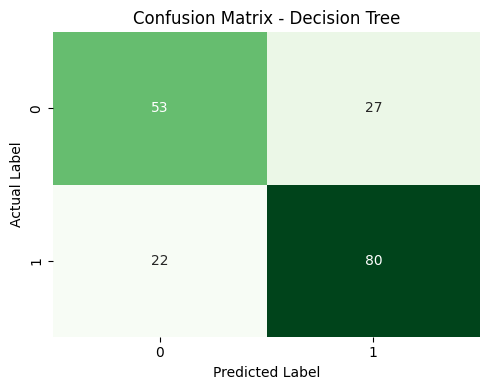

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True, fmt="d", cmap="Greens",cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

- The confusion matrix shows that the model correctly classified 53 negative cases and 80 positive cases. There were 27 false positives and 22 false negatives.
- The model demonstrates stronger performance in identifying positive (disease) cases compared to negative cases.
- The relatively lower number of false negatives is particularly important in medical diagnosis, as failing to detect a disease can have serious consequences.

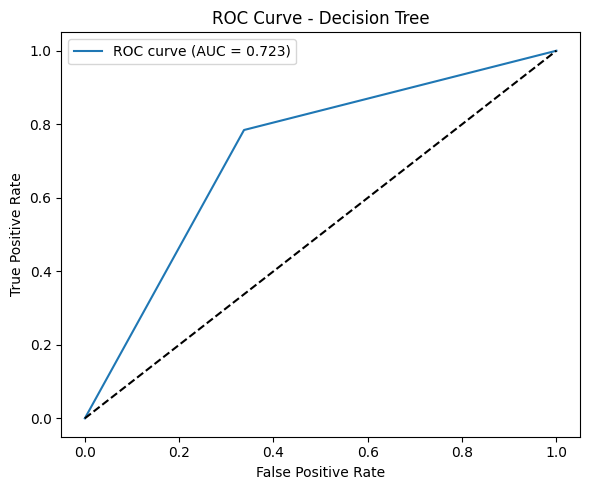

In [23]:
# ROC Curve
if y_proba is not None:
    from sklearn.metrics import roc_curve, auc
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc(fpr, tpr):.3f})")
    plt.plot([0,1],[0,1],"--", color="black")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Decision Tree")
    plt.legend()
    plt.tight_layout()
    plt.show()

- The ROC curve demonstrates the model’s ability to distinguish between patients with and without heart disease.
- The AUC value of approximately 0.72 indicates that the model has acceptable discriminatory power and performs very good.

### Hyperparameter Tuning:

In [24]:
# Define hyperparameter grid
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}                             

In [25]:
# Initialize Decision Tree with balanced class weights
dt_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')

In [26]:
grid_search = GridSearchCV(
    estimator=dt_clf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [27]:
best_clf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV F1-score: 0.778741970217301


The tuned Decision Tree model showed improved performance compared to the baseline model, indicating that hyperparameter optimization enhanced the model’s predictive ability.

In [28]:
# Evaluate tuned model on test set
y_pred_best = best_clf.predict(X_test)
y_proba_best = best_clf.predict_proba(X_test)[:,1] if hasattr(best_clf,"predict_proba") else None

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Tuned Recall:", recall_score(y_test, y_pred_best, zero_division=0))
print("Tuned F1-score:", f1_score(y_test, y_pred_best, zero_division=0))
if y_proba_best is not None:
    print("Tuned ROC-AUC:", roc_auc_score(y_test, y_proba_best))

Tuned Accuracy: 0.6978021978021978
Tuned Precision: 0.7640449438202247
Tuned Recall: 0.6666666666666666
Tuned F1-score: 0.7120418848167539
Tuned ROC-AUC: 0.7826593137254902


- Although hyperparameter tuning improved the ROC-AUC score, the F1-score on the test set slightly decreased compared to the baseline model.
- This suggests that while the tuned model has better discrimination ability, the overall classification balance did not significantly improve.

### Model Evaluation and Analysis:

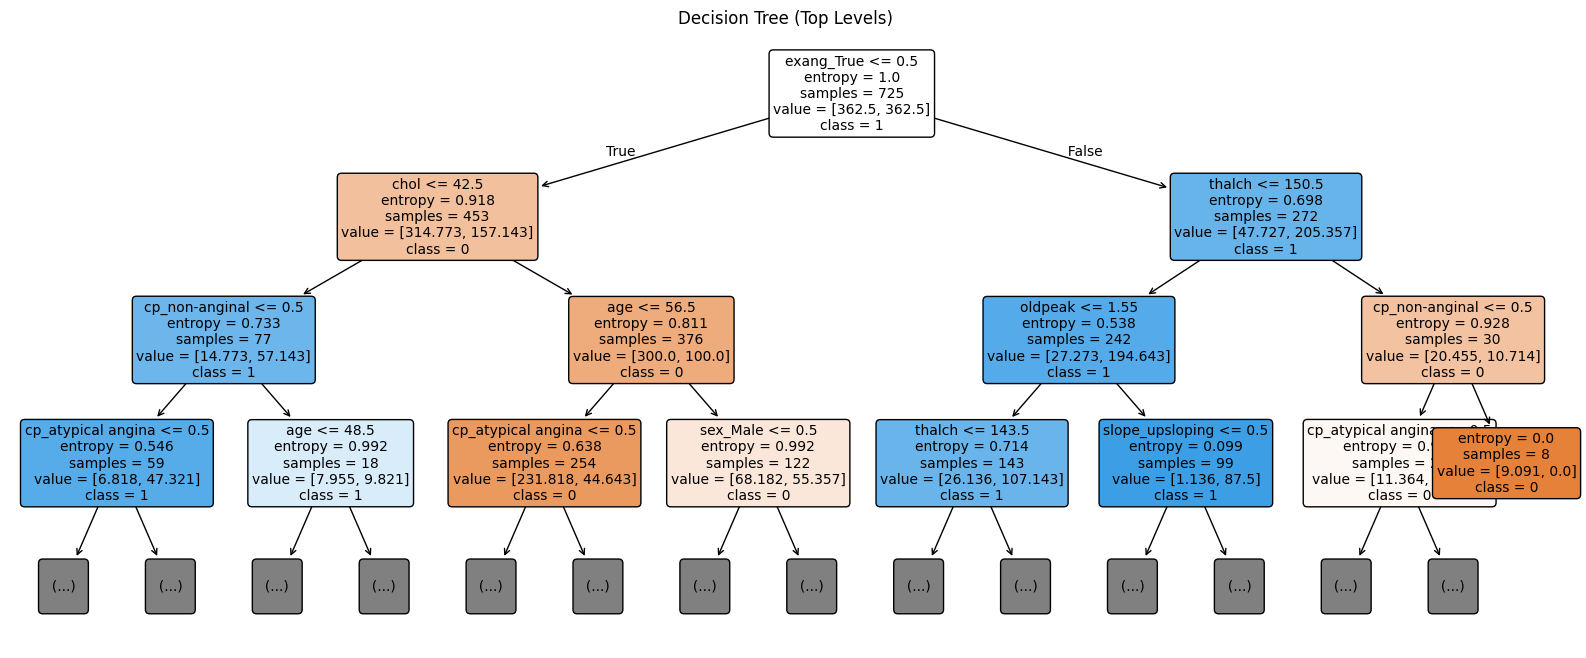

In [29]:
# Visualize top levels of the tuned tree (for readability)
plt.figure(figsize=(20,8))
tree.plot_tree(
    best_clf,
    feature_names=X_train.columns,
    class_names=[str(c) for c in best_clf.classes_],
    filled=True,
    rounded=True,
    max_depth=3,  
    fontsize=10
)
plt.title("Decision Tree (Top Levels)")
plt.show()


In [30]:
# Feature importance
importances = best_clf.feature_importances_
imp_df = pd.DataFrame({"feature": X_train.columns, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(10)

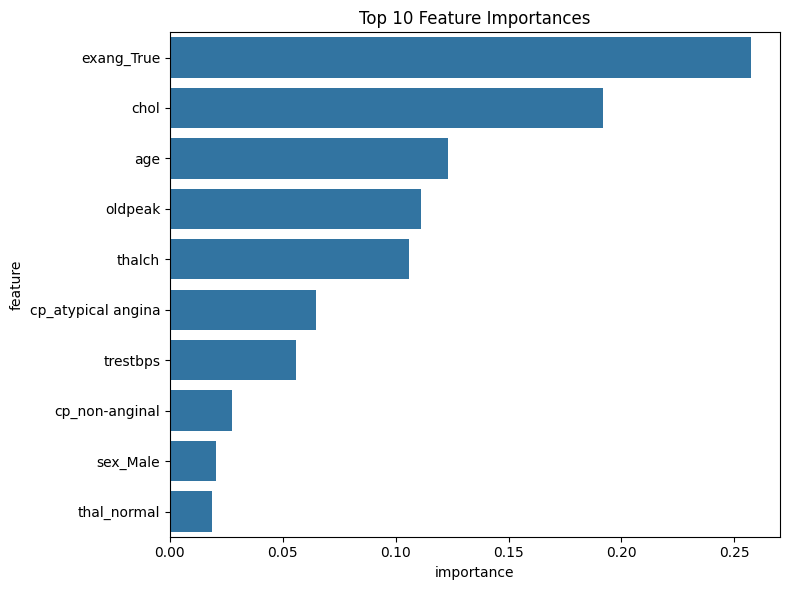

In [31]:
# Bar plot
plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=imp_df)
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

- The feature importance plot shows that exang (exercise-induced angina) is the most influential predictor in the tuned Decision Tree model.
- Other important variables include cholesterol (chol), age, oldpeak, and maximum heart rate achieved (thalach).
- These features significantly contribute to classification decisions, while lower-ranked features have comparatively minimal impact.
- The results align with the decision tree structure, confirming that the model relies heavily on a few key predictors.

#### Conclusion

- In this project, I first prepared and explored the dataset. Then, I built a baseline Decision Tree model and evaluated its performance using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.
- Next, I applied hyperparameter tuning using Grid Search with cross-validation to improve the model. I evaluated the tuned model on the test set and compared its performance with the baseline model.
- Finally, I visualized the decision tree and analysed feature importance to understand how the model makes predictions.
- Overall, the tuned Decision Tree provides interpretable results with satisfactory predictive performance.

### Interview Questions:


**1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?**


Some common hyperparameters in a Decision Tree are:

1. max_depth – This controls how deep the tree can grow. If the tree is very deep, it may learn too much from training data and overfit. If it is too shallow, it may not learn enough.
2. min_samples_split – This decides the minimum number of samples needed to split a node. A larger value makes the tree simpler and helps reduce overfitting.
3. min_samples_leaf – This sets the minimum number of samples required in a leaf node. Higher values make the model more stable and improve generalization.
4. criterion (gini or entropy) – This is used to measure how good a split is. It helps the model choose the best feature to split the data.
5. class_weight – This is used when the dataset is imbalanced. It gives more importance to the minority class.

These hyperparameters control how complex the tree becomes. By tuning them properly, we can improve the model’s performance and avoid overfitting.


**2. What is the difference between the Label encoding and One-hot encoding?**

- Label Encoding converts each category into a unique number. For example, if we have categories like Red, Blue, and Green, they may be converted to 0, 1, and 2. This method is simple but it may create an unwanted order between categories, even if no real order exists.
- One-Hot Encoding creates a separate column for each category. For example, Red, Blue, and Green will become three different columns, and only one column will have the value 1 for each row while the others will be 0. This method does not create any order between categories.